In [1]:
# Turkish
# histopatolojik meme kanseri görüntülerinin U-Net tabanlı segmentasyon, ROI çıkarımı, 
# MobileNetV2 sınıflandırması ve Grad-CAM açıklanabilirliği 

# ÖZGÜNLÜK-U-Net ile önce lezyon buluyorum
#Sonra bu bilgiyi sınıflandırmaya aktarıyorum
#Ardından Grad-CAM ile kararı görselleştiriliyorum
#Yani Segmentasyon > ROI > Sınıflandırma > Açıklama
#tek bir sistem içinde karşılaştırmalı olarak inceleniyor.
#Literatürde bu adımlar genelde: ya ayrı ayrı , ya da açıklamasız şekilde yapılıyor
              
# English 
# U-Net based segmentation, ROI extraction, MobileNetV2 classification, and Grad-CAM explainability of histopathological breast cancer images.
# NOVELTY - First, I identify the lesion using U-Net.
# Then, I transfer this information to the classification stage.
# Subsequently, I visualize the decision using Grad-CAM.
# In other words; Segmentation > ROI > Classification > Explanation
# are analyzed comparatively within a single system.
# In the literature, these steps are generally performed: either separately or without explanation.


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

print(os.listdir("/kaggle/input"))

['u-net-dat', 'breast-dataset']


In [2]:
import os
print(os.listdir("/kaggle/input/u-net-dat"))

['u-net dataset']


In [3]:
import os

base = "/kaggle/input/u-net-dat"
for item in os.listdir(base):
    print(item, "→", os.listdir(os.path.join(base, item)) if os.path.isdir(os.path.join(base, item)) else "")

u-net dataset → ['images', 'masks']


In [4]:
import os

UNET_BASE_PATH = "/kaggle/input/u-net-dat/u-net dataset"

UNET_IMAGE_PATH = os.path.join(UNET_BASE_PATH, "images")
UNET_MASK_PATH  = os.path.join(UNET_BASE_PATH, "masks")

print("Image folder exists:", os.path.exists(UNET_IMAGE_PATH))
print("Mask folder exists :", os.path.exists(UNET_MASK_PATH))

print("Image classes:", os.listdir(UNET_IMAGE_PATH))
print("Mask classes :", os.listdir(UNET_MASK_PATH))

Image folder exists: True
Mask folder exists : True
Image classes: ['benign', 'malignant']
Mask classes : ['benign', 'malignant']


In [5]:
import os

UNET_BASE_PATH = "/kaggle/input/u-net-dat/u-net dataset"
UNET_IMAGE_PATH = os.path.join(UNET_BASE_PATH, "images")
UNET_MASK_PATH  = os.path.join(UNET_BASE_PATH, "masks")


for cls in ["benign", "malignant"]:
    img_dir = os.path.join(UNET_IMAGE_PATH, cls)
    mask_dir = os.path.join(UNET_MASK_PATH, cls)

    imgs = sorted(os.listdir(img_dir))
    masks = sorted(os.listdir(mask_dir))

    print(f"\nClass: {cls}")
    print("Image count:", len(imgs))
    print("Mask  count:", len(masks))

    # İsim eşleşme kontrolü
    for i in range(5):
        print(" ", imgs[i], "↔", masks[i])


Class: benign
Image count: 210
Mask  count: 210
  benign (1).png ↔ benign (1)_mask.png
  benign (10).png ↔ benign (10)_mask.png
  benign (100).png ↔ benign (100)_mask.png
  benign (101).png ↔ benign (101)_mask.png
  benign (102).png ↔ benign (102)_mask.png

Class: malignant
Image count: 210
Mask  count: 210
  malignant (1).png ↔ malignant (1)_mask.png
  malignant (10).png ↔ malignant (10)_mask.png
  malignant (100).png ↔ malignant (100)_mask.png
  malignant (101).png ↔ malignant (101)_mask.png
  malignant (102).png ↔ malignant (102)_mask.png


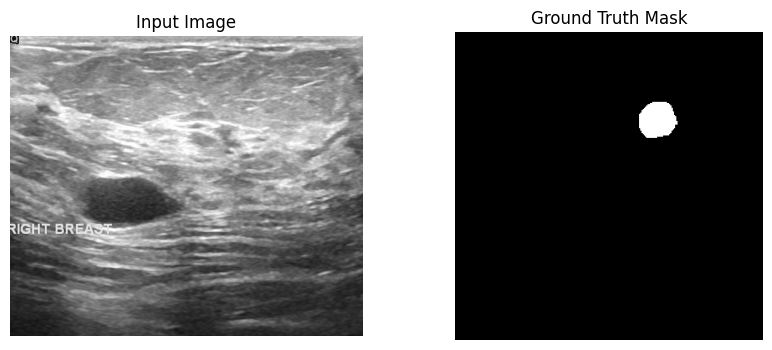

Mask min/max: 0.0 1.0
Mask shape: (256, 256, 1)


In [6]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Base Paths
UNET_BASE_PATH = "/kaggle/input/u-net-dat/u-net dataset"
UNET_IMAGE_PATH = os.path.join(UNET_BASE_PATH, "images")
UNET_MASK_PATH  = os.path.join(UNET_BASE_PATH, "masks")

# Select target class
cls = "benign"  # Or "malignant"

# Class folders full path
img_dir  = os.path.join(UNET_IMAGE_PATH, cls)
mask_dir = os.path.join(UNET_MASK_PATH, cls)

# Select sample image & mask
img_name  = os.listdir(img_dir)[0]
mask_name = os.listdir(mask_dir)[0]

img_path  = os.path.join(img_dir, img_name)
mask_path = os.path.join(mask_dir, mask_name)

# Görüntüyü yükle ve normalize et
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Loud the mask and convert to binary
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (256, 256))           # UNet input size
mask = (mask > 0).astype("float32")           # Binary mask
mask = np.expand_dims(mask, axis=-1)

# Visualize
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask[:,:,0], cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")
plt.show()

print("Mask min/max:", mask.min(), mask.max())
print("Mask shape:", mask.shape)

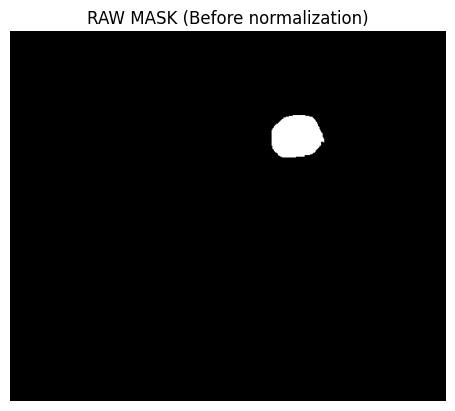

Raw mask min-max: 0 255


In [7]:
raw_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(raw_mask, cmap="gray")
plt.title("RAW MASK (Before normalization)")
plt.axis("off")
plt.show()

print("Raw mask min-max:", raw_mask.min(), raw_mask.max())

In [8]:
mask = (raw_mask > 0).astype("float32")

# Solution for small Tumor problem

kernel = np.ones((3,3), np.uint8)
mask = cv2.dilate(mask, kernel, iterations=1)

mask = np.expand_dims(mask, axis=-1)

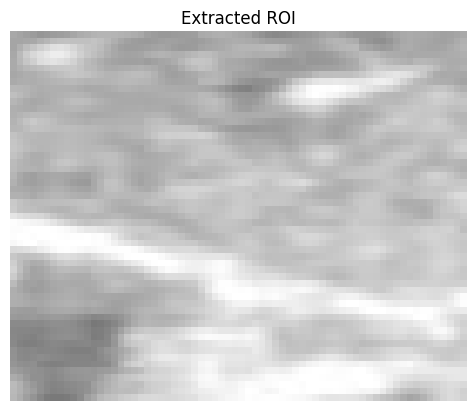

In [9]:
ys, xs = np.where(mask.squeeze() == 1)

if len(xs) > 0:
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    roi = img[y_min:y_max, x_min:x_max]

    plt.imshow(roi)
    plt.title("Extracted ROI")
    plt.axis("off")
    plt.show()
else:
    print("ROI bulunamadı")

In [10]:
# Necessary Libraries

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50


#ResNet50-backbon U-Net (256x256 output)
def build_resnet_unet_256(input_size=(256,256,3)):
    
    # Encoder (ResNet50)
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_size
        
    )
    base_model.trainable = False


    # Encoder l (skip connections)
    
    s1 = base_model.get_layer("conv1_relu").output         # 128x128
    s2 = base_model.get_layer("conv2_block3_out").output   # 64x64
    s3 = base_model.get_layer("conv3_block4_out").output   # 32x32
    s4 = base_model.get_layer("conv4_block6_out").output   # 16x16

    b  = base_model.get_layer("conv5_block3_out").output   # 8x8

    # Decoder
    # D1: 8x8 -> 16x16
    d1 = UpSampling2D(size=(2,2))(b)
    d1 = Concatenate()([d1, s4])
    d1 = Conv2D(512, 3, padding="same", activation="relu")(d1)

    # D2: 16x16 -> 32x32
    d2 = UpSampling2D(size=(2,2))(d1)
    d2 = Concatenate()([d2, s3])
    d2 = Conv2D(256, 3, padding="same", activation="relu")(d2)

    # D3: 32x32 -> 64x64
    d3 = UpSampling2D(size=(2,2))(d2)
    d3 = Concatenate()([d3, s2])
    d3 = Conv2D(128, 3, padding="same", activation="relu")(d3)

    # D4: 64x64 -> 128x128
    d4 = UpSampling2D(size=(2,2))(d3)
    d4 = Concatenate()([d4, s1])
    d4 = Conv2D(64, 3, padding="same", activation="relu")(d4)

    # D5: 128x128 -> 256x256 (final upsampling)
    d5 = UpSampling2D(size=(2,2))(d4)
    d5 = Conv2D(32, 3, padding="same", activation="relu")(d5)

    # Output layer
    outputs = Conv2D(1, 1, activation="sigmoid")(d5)   # 256x256 output

    model = Model(inputs=base_model.input, outputs=outputs)
    return model

    # Modeli oluştur
unet = build_resnet_unet_256()

2026-04-02 19:17:06.431336: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775157426.610973      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775157426.662703      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775157427.074397      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775157427.074441      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775157427.074445      55 computation_placer.cc:177] computation placer alr

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
import cv2
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D,
    Concatenate, BatchNormalization, Dropout, Activation
)

def unet_generator(img_dir, mask_dir, batch_size=8, target_size=(256,256)):

    img_paths  = []
    mask_paths = []

    for cls in ["benign", "malignant"]:

        img_cls_dir  = os.path.join(img_dir, cls)
        mask_cls_dir = os.path.join(mask_dir, cls)

        imgs  = sorted(os.listdir(img_cls_dir))
        masks = sorted(os.listdir(mask_cls_dir))


        for img_name in imgs:

            # Remove PNG extention
            
            base = img_name.replace(".png", "")

            # Generate mask name
            
            mask_name = base + "_mask.png"
            

            if mask_name in masks:

                img_paths.append(
                    os.path.join(img_cls_dir, img_name)
                )

                mask_paths.append(
                    os.path.join(mask_cls_dir, mask_name)
                )


    N = len(img_paths)
    print("Total matched samples:", N)


    while True:

        idxs = np.random.permutation(N)

        for i in range(0, N, batch_size):

            batch_idx = idxs[i:i+batch_size]

            imgs, masks = [], []


            for j in batch_idx:

                # IMAGE
                img = cv2.imread(img_paths[j])
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, target_size)
                img = img.astype(np.float32) / 255.0


                # MASK
                mask = cv2.imread(mask_paths[j], cv2.IMREAD_GRAYSCALE)

                if mask is None:
                    print("MASK NOT FOUND:", mask_paths[j])
                    continue


                mask = cv2.resize(
                    mask,
                    target_size,
                    interpolation=cv2.INTER_NEAREST
                )

                mask = (mask > 127).astype(np.float32)
                mask = np.expand_dims(mask, -1)


                # AUGMENT
                if np.random.rand() < 0.5:
                    img  = np.fliplr(img)
                    mask = np.fliplr(mask)

                if np.random.rand() < 0.3:

                    angle = np.random.uniform(-10, 10)

                    M = cv2.getRotationMatrix2D(
                        (target_size[0]//2, target_size[1]//2),
                        angle,
                        1
                    )

                    img = cv2.warpAffine(img, M, target_size)

                    mask = cv2.warpAffine(
                        mask,
                        M,
                        target_size,
                        flags=cv2.INTER_NEAREST
                    )

                    mask = np.expand_dims(mask, -1)


                # APPEND
                imgs.append(img)
                masks.append(mask)


            if len(imgs) == 0:
                continue


            yield np.array(imgs), np.array(masks)

In [12]:
TRAIN_IMG_DIR = UNET_IMAGE_PATH
TRAIN_MASK_DIR = UNET_MASK_PATH

batch_size = 8
train_gen = unet_generator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, batch_size=batch_size)

In [13]:
gen = unet_generator(TRAIN_IMG_DIR, TRAIN_MASK_DIR, batch_size=4)

x, y = next(gen)

print("X shape:", x.shape)
print("Y shape:", y.shape)

print("Mask unique:", np.unique(y))

Total matched samples: 420
X shape: (4, 256, 256, 3)
Y shape: (4, 256, 256, 1)
Mask unique: [0. 1.]


In [14]:
# Compile focal + dice loss Or any loss of your choice

def dice_loss(y_true, y_pred, smooth=1e-6):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - tf.reduce_mean(dice)

def focal_loss(y_true, y_pred, alpha=0.8, gamma=2.0):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    pt = tf.exp(-bce)
    return tf.reduce_mean(alpha * (1-pt)**gamma * bce)

def focal_dice_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

def dice_coef(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    return tf.reduce_mean((2. * intersection + 1e-6) / (union + 1e-6))

In [15]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        patience=5,
        factor=0.5,
        verbose=1
    )
]

In [16]:
# Image: 0-1 normalize

img = img / 255.0

size = (256,256)
# Mask -> 0-1 binary
mask = (mask > 0).astype(np.float32)
mask = np.expand_dims(mask, axis=-1)

In [17]:
import os

# Train directory image count

num_benign    = len(os.listdir(os.path.join(TRAIN_IMG_DIR, "benign")))
num_malignant = len(os.listdir(os.path.join(TRAIN_IMG_DIR, "malignant")))

total_images = num_benign + num_malignant

batch_size = 8  # Based on generator batch size

# Number of steps per epoch 

steps_per_epoch = total_images // batch_size

In [18]:

from tensorflow.keras.optimizers import Adam

# Compile
unet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_dice_loss,
    metrics=[dice_coef]
)
history = unet.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    callbacks=callbacks
)

Total matched samples: 420
Epoch 1/50


I0000 00:00:1775157488.758618     126 service.cc:152] XLA service 0x7ee800001970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775157488.758657     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775157490.862743     126 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/52 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - dice_coef: 0.1570 - loss: 0.9512  

I0000 00:00:1775157500.508407     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 229ms/step - dice_coef: 0.2062 - loss: 0.8851 - learning_rate: 1.0000e-04
Epoch 2/50


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: dice_coef,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: dice_coef,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
2026-04-02 19:18:36.414603: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 19:18:36.674616: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 98ms/step - dice_coef: 0.2273 - loss: 0.8561 - learning_rate: 1.0000e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - dice_coef: 0.2585 - loss: 0.8356 - learning_rate: 1.0000e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - dice_coef: 0.2347 - loss: 0.8411 - learning_rate: 1.0000e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - dice_coef: 0.2536 - loss: 0.8339 - learning_rate: 1.0000e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 167ms/step - dice_coef: 0.2712 - loss: 0.8135 - learning_rate: 1.0000e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - dice_coef: 0.2385 - loss: 0.8438 - learning_rate: 1.0000e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - dice_coef: 0.2498 - loss: 0.8281 - learning_rate: 1.0000e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - dice_coef: 0.2772 - loss: 0.8079 - learning_rate: 1.0000e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - dice_coef: 0.2548 - loss: 0.8334 - lea

In [19]:
for layer in unet.layers[-40:]:
    layer.trainable = True

In [20]:
unet.compile(
    optimizer=tf.keras.optimizers.Adam(5e-5),
    loss=focal_dice_loss,
    metrics=[dice_coef]
)
history2 = unet.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 241ms/step - dice_coef: 0.3565 - loss: 0.8407 - learning_rate: 5.0000e-05
Epoch 2/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - dice_coef: 0.4002 - loss: 0.7103 - learning_rate: 5.0000e-05
Epoch 3/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - dice_coef: 0.3898 - loss: 0.7293 - learning_rate: 5.0000e-05
Epoch 4/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - dice_coef: 0.4545 - loss: 0.6511 - learning_rate: 5.0000e-05
Epoch 5/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - dice_coef: 0.4718 - loss: 0.6462 - learning_rate: 5.0000e-05
Epoch 6/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - dice_coef: 0.4540 - loss: 0.6641 - learning_rate: 5.0000e-05
Epoch 7/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - dice_coef: 0.4435 - loss: 0.6645 - learning_rate: 5.0000e-05
Epoch 8/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - dice_coef: 0.4802 - loss: 0.6137 - learning_rate: 5.0000e-05
Epoch 9/40
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - dice_coef: 0.5264 - loss:

In [21]:
# Post-training model saving 
unet.save("/kaggle/working/unet_full_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
Dice score on batch: 0.74635965


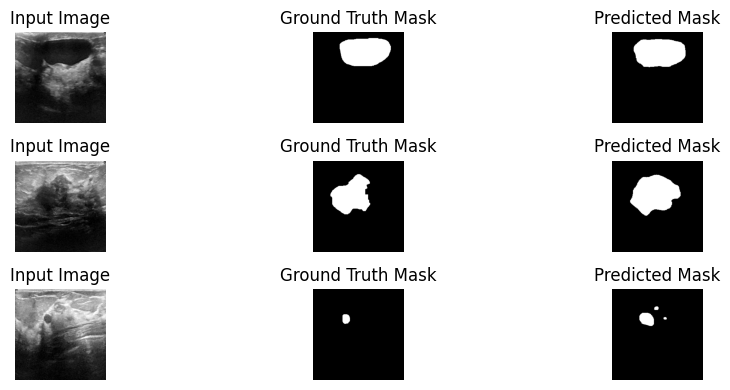

In [22]:
# Get a batch from the generator 
x_batch, y_batch = next(train_gen)

# Inference with the model
pred_mask = unet.predict(x_batch)

# Binary mask
pred_mask_bin = (pred_mask > 0.4).astype(np.float32)

# Dice score for the batch 
intersection = np.sum(pred_mask_bin * y_batch)
union = np.sum(pred_mask_bin) + np.sum(y_batch)
dice_score = (2*intersection + 1e-3) / (union + 1e-6)
print("Dice score on batch:", dice_score)

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
for i in range(3):  # First 3 image
    plt.subplot(3,3,i*3+1)
    plt.imshow(x_batch[i])
    plt.title("Input Image")
    plt.axis("off")
    
    plt.subplot(3,3,i*3+2)
    plt.imshow(y_batch[i,:,:,0], cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    plt.subplot(3,3,i*3+3)
    plt.imshow(pred_mask_bin[i,:,:,0], cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")
    plt.tight_layout()
plt.show()


In [23]:
x_batch, y_batch = next(train_gen)

pred = unet.predict(x_batch)

print("Pred min/max:", pred.min(), pred.max())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Pred min/max: 2.3094209e-25 0.99979305


In [24]:
unet = tf.keras.models.load_model(
    "/kaggle/working/unet_full_model.h5",
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

In [25]:
import os
print(os.listdir("/kaggle/input/breast-dataset"))

['breast_dataset']


In [26]:
print(os.listdir("/kaggle/input/breast-dataset/breast_dataset"))

['val', 'test', 'train']


In [27]:

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
base_path = "/kaggle/input/breast-dataset/breast_dataset/train/malignant"
print(os.listdir(base_path)[:8]);

['10262_idx5_x1351_y951_class1.png', '10262_idx5_x1251_y1951_class1.png', '10264_idx5_x1101_y1451_class1.png', '10273_idx5_x1901_y1701_class1.png', '10277_idx5_x1051_y951_class1.png', '10275_idx5_x1101_y851_class1.png', '10273_idx5_x851_y751_class1.png', '10254_idx5_x1751_y1251_class1.png']


In [28]:
base_path = "/kaggle/input/breast-dataset/breast_dataset/train/malignant"

img_name = os.listdir(base_path)[0]
img_path = os.path.join(base_path, img_name)

In [29]:
def preprocess_for_unet(img_path, size=(256,256)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img.astype(np.float32)/255.0
    return img

In [30]:
img_unet = preprocess_for_unet(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Mask pixels: 24360


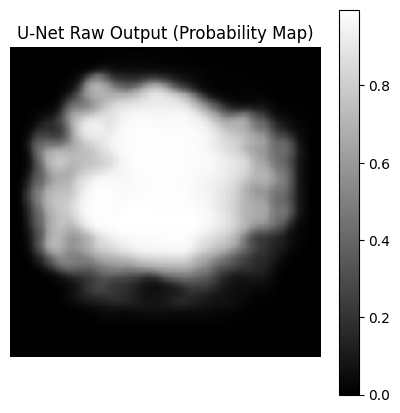

In [31]:
pred = unet.predict(img_unet[None,...])[0]

# Adaptif threshold
th = 0.5 * pred.max()

binary = (pred > th).astype(np.uint8)

# Extract the largest region
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

if num_labels > 1:
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    binary = (labels == largest).astype(np.uint8)

# Morphological cleaning
kernel = np.ones((5,5), np.uint8)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

print("Mask pixels:", np.sum(binary))


# RAW U-NET OUTPUT
plt.figure(figsize=(5,5))
plt.imshow(pred[:,:,0], cmap="gray")
plt.title("U-Net Raw Output (Probability Map)")
plt.colorbar()
plt.axis("off")
plt.show()

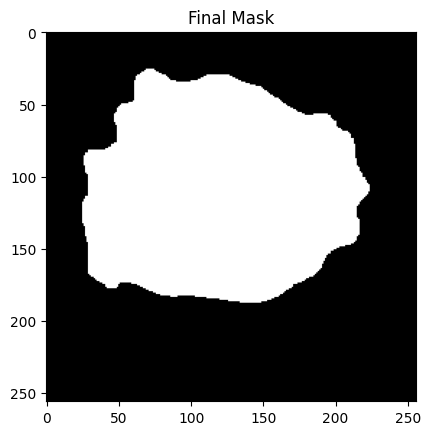

In [32]:
plt.imshow(binary, cmap="gray")
plt.title("Final Mask")
plt.show()

In [33]:
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

Pred min/max: 8.068765e-24 0.996706


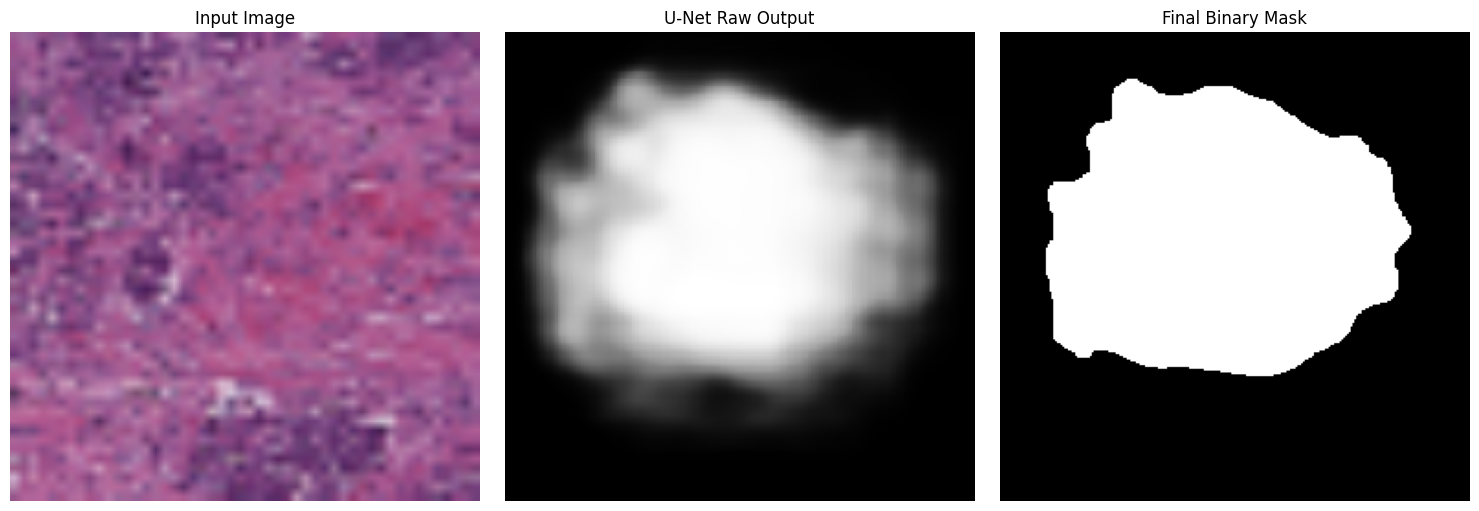

In [34]:
print("Pred min/max:", pred.min(), pred.max())
plt.figure(figsize=(15,5))

# Input
plt.subplot(1,3,1)
plt.imshow(img_unet)
plt.title("Input Image")
plt.axis("off")

# Raw U-Net Output
plt.subplot(1,3,2)
plt.imshow(pred[:,:,0], cmap="gray")
plt.title("U-Net Raw Output")
plt.axis("off")

# Final Binary Mask
plt.subplot(1,3,3)
plt.imshow(binary, cmap="gray")
plt.title("Final Binary Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

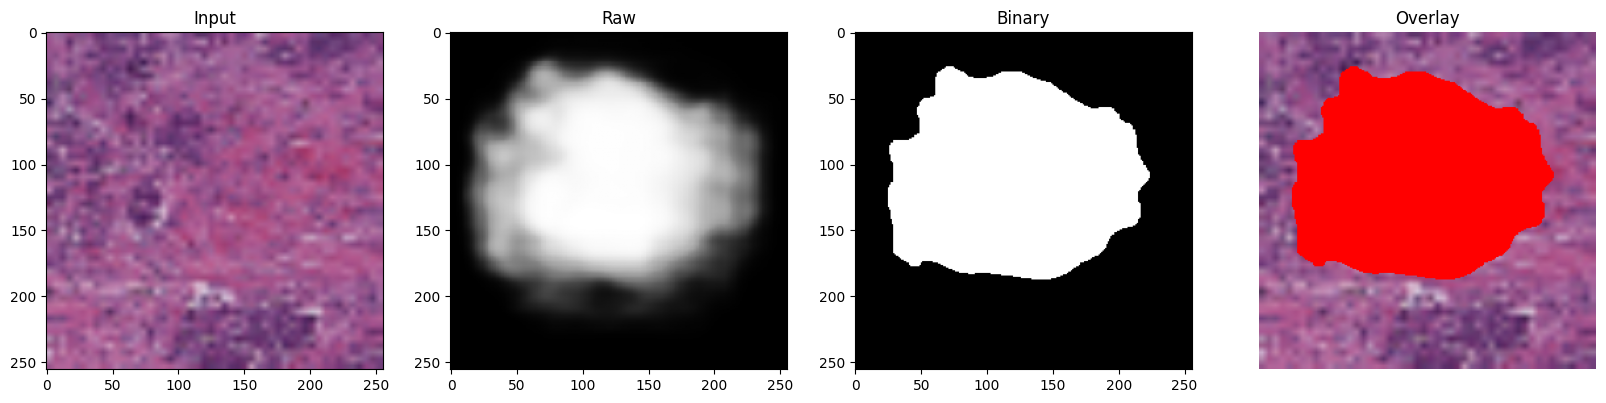

In [35]:
overlay = img_unet.copy()
overlay[binary == 1] = [255, 0, 0]

plt.figure(figsize=(20,5))

plt.subplot(1,4,1)
plt.imshow(img_unet)
plt.title("Input")

plt.subplot(1,4,2)
plt.imshow(pred[:,:,0], cmap="gray")
plt.title("Raw")

plt.subplot(1,4,3)
plt.imshow(binary, cmap="gray")
plt.title("Binary")

plt.subplot(1,4,4)
plt.imshow(overlay)
plt.title("Overlay")

plt.axis("off")
plt.show()

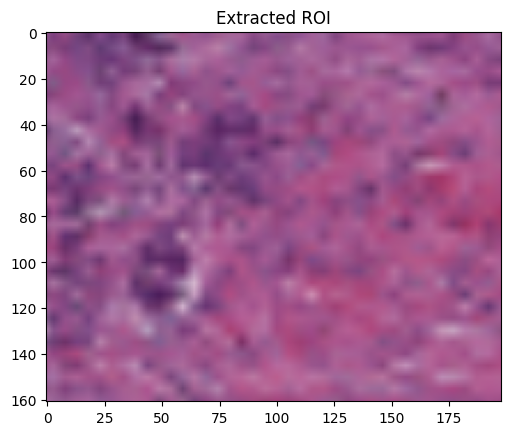

In [36]:
#x_min x_max, y_min y_max  ROI coordinates in the orijinal image

ys, xs = np.where(binary == 1)

if len(xs) == 0:
    print("No lesion detected")
else:
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    roi = img_unet[y_min:y_max, x_min:x_max]

    plt.imshow(roi)
    plt.title("Extracted ROI")
    plt.show()

In [37]:
roi_resized = cv2.resize(roi, (224,224))
roi_norm = roi_resized / 255.0
roi_input = np.expand_dims(roi_norm, axis=0)

In [38]:
# MobileNetV2 defination

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)
model = Model(inputs=base_model.input, outputs=output)

# Train only the necessary layers
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-4,
    decay_steps=steps_per_epoch*40,
    alpha=1e-2  # min lr = lr*0.01
)
optimizer = Adam(lr_schedule)

model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "/kaggle/input/breast-dataset/breast_dataset"


train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8,1.2]
)
val_gen = ImageDataGenerator(rescale=1./255)

In [41]:
# Training preparation for MobilNetV2 

train_data = train_gen.flow_from_directory(
    data_dir + "/train",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    data_dir + "/val",
    target_size=(224,224),
    batch_size=16,
    class_mode="binary"
)
class_weight = {0: 3, 1: 1}  # 0=benign, 1=malignant

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.


In [42]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [43]:
# MobilNetV2 training; here ım training the clasifier in its base from without segmentation

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


2026-04-02 19:47:29.286415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-02 19:47:29.482021: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


438/438 ━━━━━━━━━━━━━━━━━━━━ 158s 315ms/step - accuracy: 0.7315 - loss: 0.8025 - val_accuracy: 0.8293 - val_loss: 0.4395 - learning_rate: 8.9558e-05
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.8048 - loss: 0.6048 - val_accuracy: 0.5000 - val_loss: 1.4950 - learning_rate: 6.2636e-05
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.8270 - loss: 0.5473 - val_accuracy: 0.5380 - val_loss: 0.9294 - learning_rate: 3.0594e-05
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.8396 - loss: 0.5122 - val_accuracy: 0.6413 - val_loss: 0.7684 - learning_rate: 6.9511e-06
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 183ms/step - accuracy: 0.8395 - loss: 0.5166 - val_accuracy: 0.7347 - val_loss: 0.5809 - learning_rate: 1.0000e-06
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 185ms/step - accuracy: 0.8514 - loss: 0.4869 - val_accuracy: 0.7713 - val_loss: 0.4866 - learning_rate: 1.0000e-06
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step -

In [44]:
model.save("/kaggle/working/mobilenet_roi_classifier.h5")

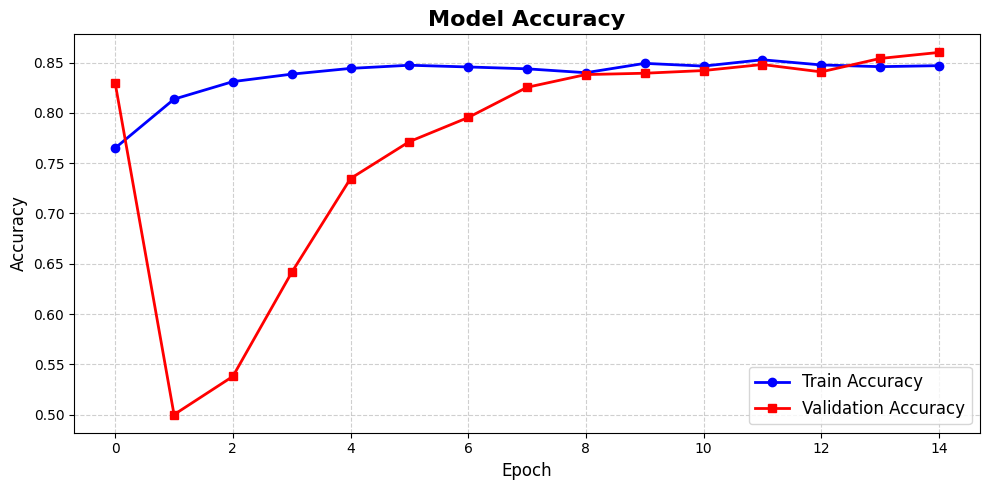

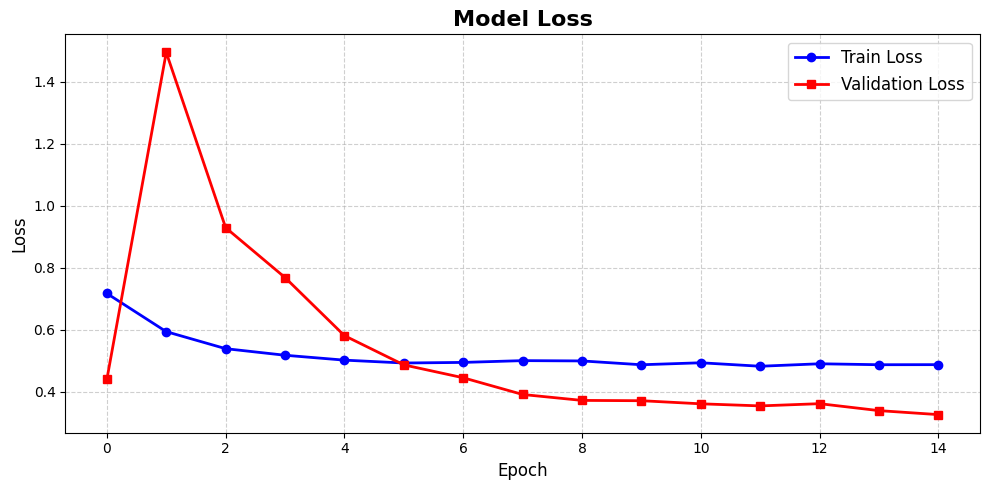

In [45]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], 'b-o', label='Train Accuracy', linewidth=2, markersize=6)
plt.plot(history.history['val_accuracy'], 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
plt.title('Model Accuracy', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Loss plot 
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], 'b-o', label='Train Loss', linewidth=2, markersize=6)
plt.plot(history.history['val_loss'], 'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.title('Model Loss', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [46]:
print(train_data)
print(val_data)

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_gen = ImageDataGenerator(rescale=1./255)
IMG_SIZE = (224, 224)

test_data = test_gen.flow_from_directory(
    data_dir + "/test",
    target_size=IMG_SIZE,
    batch_size=16,
    class_mode="binary",
    shuffle=False
)

Found 1500 images belonging to 2 classes.


In [48]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.8355 - loss: 0.3555
Test Accuracy: 0.8299999833106995


In [49]:
import numpy as np

y_prob_prop = model.predict(test_data).flatten()
y_pred_prop = (y_prob_prop > 0.4).astype(int)
y_true = test_data.classes
print("Proposed Model predictions saved")

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step
Proposed Model predictions saved


In [50]:
import numpy as np
from sklearn.metrics import classification_report

y_prob_prop = model.predict(test_data).flatten()
y_pred_prop = (y_prob_prop > 0.4).astype(int)
y_true = test_data.classes

print("Proposed model predictions saved")



print("-- PROPOSED MODEL CLASSIFICATION REPORT --")
print(classification_report(
    y_true, y_pred_prop,
    target_names=["Benign","Malignant"]
))

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
Proposed model predictions saved
-- PROPOSED MODEL CLASSIFICATION REPORT --
              precision    recall  f1-score   support

      Benign       0.83      0.83      0.83       750
   Malignant       0.83      0.83      0.83       750

    accuracy                           0.83      1500
   macro avg       0.83      0.83      0.83      1500
weighted avg       0.83      0.83      0.83      1500



94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step


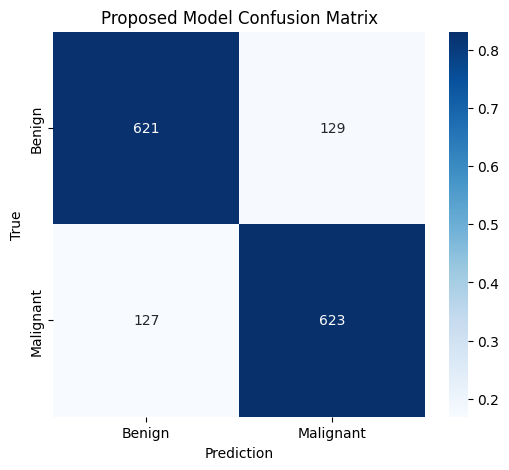

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Retrive prediction and actual values
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.4).astype(int).flatten()  
y_true = test_data.classes

# Generate confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize

# Visualize
plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=cm, fmt='g', cmap='Blues', xticklabels=['Benign','Malignant'], yticklabels=['Benign','Malignant'])
plt.xlabel('Prediction')
plt.ylabel('True')
plt.title('Proposed Model Confusion Matrix')
plt.show()

In [53]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


base_path = "/kaggle/input/breast-dataset/breast_dataset/test/malignant"
print(os.listdir(base_path)[:5]);

['10273_idx5_x2201_y1351_class1.png', '10260_idx5_x751_y851_class1.png', '10269_idx5_x1801_y401_class1.png', '10262_idx5_x2051_y1101_class1.png', '10273_idx5_x2001_y1751_class1.png']


First 5 files in the folder: ['10273_idx5_x2201_y1351_class1.png', '10260_idx5_x751_y851_class1.png', '10269_idx5_x1801_y401_class1.png', '10262_idx5_x2051_y1101_class1.png', '10273_idx5_x2001_y1751_class1.png']
Selected test image: /kaggle/input/breast-dataset/breast_dataset/test/malignant/10262_idx5_x2051_y1101_class1.png


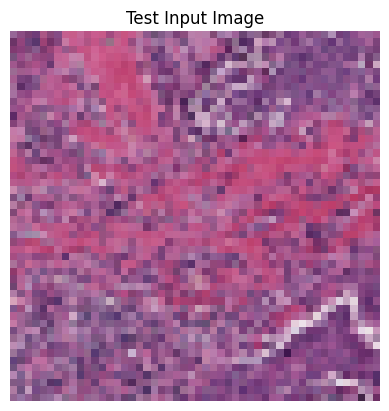

In [64]:
import os
import cv2
import matplotlib.pyplot as plt

# Test set folder
test_class = "malignant"  # Or "benign"
base_path = f"/kaggle/input/breast-dataset/breast_dataset/test/{test_class}"

# List files
files = os.listdir(base_path)
print("First 5 files in the folder:", files[:5])

# Pick first image
img_name = files[3]
img_path = os.path.join(base_path, img_name)
print("Selected test image:", img_path)

# Read & verify
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image load failed: {img_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.title("Test Input Image")
plt.axis("off")
plt.show()

In [65]:
unet = tf.keras.models.load_model(
    "/kaggle/working/unet_full_model.h5",
    custom_objects={
        "focal_dice_loss": focal_dice_loss,
        "dice_coef": dice_coef
    }
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


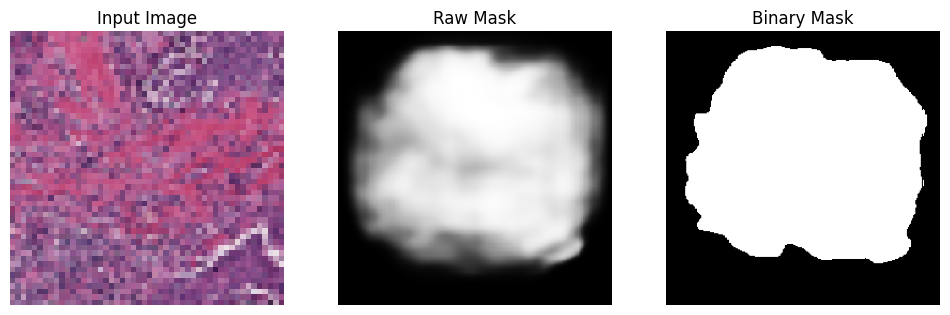

In [66]:
# U-Net Preprocessing
def preprocess_for_unet(img, size=(256,256)):
    img_resized = cv2.resize(img, size)
    img_resized = img_resized.astype("float32") / 255.0
    return img_resized

img_unet = preprocess_for_unet(img)
pred_mask = unet.predict(img_unet[None, ...])[0, :, :, 0]

# Binary mask
threshold = 0.40  # Alternative (0.5 Mean)
binary_mask = (pred_mask > threshold).astype(np.uint8)

# Visualization
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(pred_mask, cmap="gray")
plt.title("Raw Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(binary_mask, cmap="gray")
plt.title(f"Binary Mask")
plt.axis("off")
plt.show()

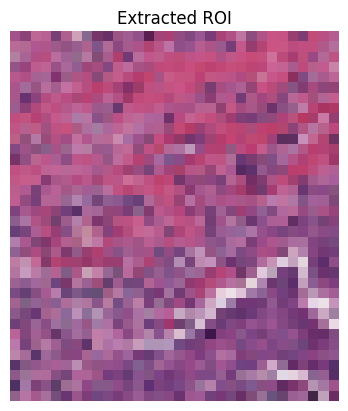

In [67]:
ys, xs = np.where(binary_mask)
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

roi = img[y_min:y_max, x_min:x_max]

plt.imshow(roi)
plt.title("Extracted ROI")
plt.axis("off")
plt.show()

In [68]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
IMG_SIZE = (224, 224)
roi_resized = cv2.resize(roi, IMG_SIZE)
roi_input = np.expand_dims(roi_resized, axis=0)


roi_input = roi_input.astype('float32') / 255.0 

In [69]:
pred = model.predict(roi_input)[0][0]
malignant_prob = pred
benign_prob = 1 - pred

print(f"Tahmin:")
print(f"Malignant: %{malignant_prob*100:.2f}")
print(f"Benign: %{benign_prob*100:.2f}")

if malignant_prob > 0.40:
    print("Final Decision: MALIGNANT")
else:
    print("Final Decision: BENIGN")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Tahmin:
Malignant: %1.36
Benign: %98.64
Final Decision: BENIGN


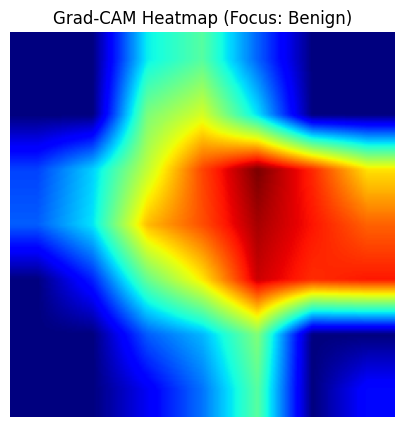

In [70]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import cv2

last_conv_layer_name = "Conv_1"  # MobileNetV2 Last Convolutional Layer
grad_model = tf.keras.Model(
    inputs=model.input,
    outputs=[model.get_layer(last_conv_layer_name).output, model.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(roi_input)
    pred_value = predictions[0, 0]
    
    
    if pred_value > 0.40:
        loss = pred_value  # For Malignant 
        predicted_class = "Malignant"
    else:
        loss = 1.0 - pred_value  # For Benign  (1 - prediction)
        predicted_class = "Benign"

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

cam = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1).numpy()
cam = np.maximum(cam, 0) # ReLU

if cam.max() > 0:
    cam = cam / cam.max()
else:
    cam = cam

cam = cv2.resize(cam, IMG_SIZE)

plt.figure(figsize=(5,5))
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM Heatmap (Focus: {predicted_class})")
plt.axis("off")
plt.show()

In [73]:
import os
import cv2
import numpy as np
import tensorflow as tf

# PATHS & LOAD IMAGE 
UNET_PATH = "/kaggle/working/unet_full_model.h5"
CLS_PATH  = "/kaggle/working/mobilenet_roi_classifier.h5"
test_class = "malignant"  # or benign
base_path = "/kaggle/input/breast-dataset/breast_dataset/test/" + test_class

files = os.listdir(base_path)
img_name = files[3]
img_path = os.path.join(base_path, img_name)

img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError("Error failed to Read image: " + img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W, _ = img.shape

# LOAD U-NET & EXTRACT ROI 
def dice_coef(y_true, y_pred): return tf.reduce_mean(y_true * y_pred)
def focal_dice_loss(y_true, y_pred): return 1 - dice_coef(y_true, y_pred)

unet = tf.keras.models.load_model(
    UNET_PATH,
    custom_objects={"focal_dice_loss": focal_dice_loss, "dice_coef": dice_coef}
)

def preprocess_for_unet(img, size=(256,256)):
    img_resized = cv2.resize(img, size)
    return img_resized.astype("float32") / 255.0

img_unet = preprocess_for_unet(img)
pred_mask = unet.predict(img_unet[None, ...])[0,:,:,0]
binary_mask = (pred_mask > 0.40).astype(np.uint8)

ys, xs = np.where(binary_mask)
y_min, y_max = ys.min(), ys.max()
x_min, x_max = xs.min(), xs.max()

# Drawing the ROI bounding box 
roi_box = img.copy()
cv2.rectangle(roi_box, (x_min,y_min), (x_max,y_max), (0,255,0), 2)
cv2.putText(roi_box, "ROI", (x_min, y_min-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)

# Preparation for ROI cropping & classifier
roi = img[y_min:y_max, x_min:x_max]
IMG_SIZE = (224,224)
roi_resized = cv2.resize(roi, IMG_SIZE)
roi_input = np.expand_dims(roi_resized, axis=0)
roi_input = roi_input.astype('float32') / 255.0  

# LOAD CLASSIFIER & PREDICT 
classifier = tf.keras.models.load_model(CLS_PATH, compile=False)

pred = classifier.predict(roi_input)[0][0]
malignant_prob = pred
benign_prob = 1 - pred


label = "MALIGNANT" if malignant_prob > 0.40 else "BENIGN"

# DYNAMİC GRAD-CAM 
last_conv_layer_name = "Conv_1"
grad_model = tf.keras.Model(
    inputs=classifier.input,
    outputs=[classifier.get_layer(last_conv_layer_name).output, classifier.output]
)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(roi_input)
    pred_value = predictions[0, 0]
    
    # Dynamic focus according to model output
    if pred_value > 0.40:
        loss = pred_value
    else:
        loss = 1.0 - pred_value

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

cam = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1).numpy()
cam = np.maximum(cam, 0) # ReLU

# Division by zero guard
if cam.max() > 0:
    cam = cam / cam.max()

cam = cv2.resize(cam, (IMG_SIZE[1], IMG_SIZE[0]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


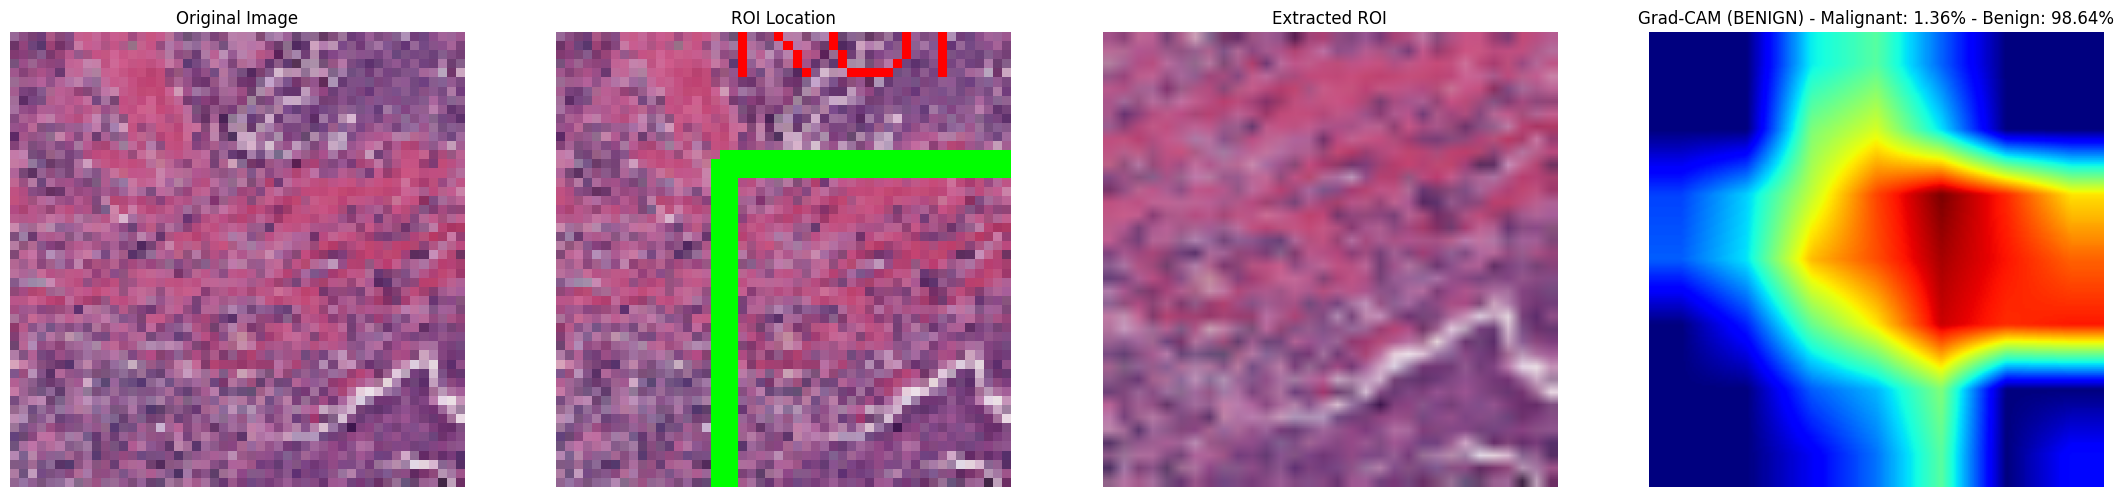

INFERENCE RESULT
ROI Coordinates: X=(18, 243), Y=(14, 216)
Prediction: BENIGN
Malignant: 1.36%
Benign: 98.64%


In [74]:
import matplotlib.pyplot as plt

# VISUALIZATION (4 PANEL)
fig, axes = plt.subplots(1,4, figsize=(22,5))

axes[0].imshow(img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(roi_box)
axes[1].set_title("ROI Location")
axes[1].axis("off")

axes[2].imshow(roi_resized)
axes[2].set_title("Extracted ROI")
axes[2].axis("off")

axes[3].imshow(cam, cmap="jet")

# Creating title text using the simplest & most secure method
t1 = "Grad-CAM (" + str(label) + ")"
t2 = "Malignant: " + str(round(malignant_prob*100, 2)) + "%"
t3 = "Benign: " + str(round(benign_prob*100, 2)) + "%"
axes[3].set_title(t1 + " - " + t2 + " - " + t3)
axes[3].axis("off")

plt.tight_layout()
plt.show()

# PRINT RESULTS 
print("INFERENCE RESULT")
print("ROI Coordinates: X=(" + str(x_min) + ", " + str(x_max) + "), Y=(" + str(y_min) + ", " + str(y_max) + ")")
print("Prediction: " + str(label))
print("Malignant: " + str(round(malignant_prob*100, 2)) + "%")
print("Benign: " + str(round(benign_prob*100, 2)) + "%")

**Model-1 (Full Image - Baseline)**

In [76]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report

DATA_DIR = "/kaggle/input/breast-dataset/breast_dataset"
TRAIN_DIR = DATA_DIR + "/train"
VAL_DIR   = DATA_DIR + "/val"
TEST_DIR  = DATA_DIR + "/test"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

# Generators (Standart 1./255 Preprocessing)
train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=15, zoom_range=0.1,
    horizontal_flip=True, vertical_flip=True, brightness_range=[0.8, 1.2]
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data_m1 = train_gen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary")
val_data_m1   = val_test_gen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary")
test_data_m1  = val_test_gen.flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

# MODEL-1 architecture
base_model1 = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
base_model1.trainable = False

x = GlobalAveragePooling2D()(base_model1.output)
x = Dropout(0.3)(x)
output1 = Dense(1, activation="sigmoid")(x)
model1 = Model(base_model1.input, output1)

model1.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6)
]

print("MODEL-1 Training is starting")
history1 = model1.fit(train_data_m1, validation_data=val_data_m1, epochs=15, callbacks=callbacks)

# TEST Predictions
y_true = test_data_m1.classes
y_prob1 = model1.predict(test_data_m1).flatten()
y_pred1 = (y_prob1 > 0.4).astype(int)

print("MODEL-1 CLASSIFICATION REPORT")
print(classification_report(y_true, y_pred1, target_names=["Benign", "Malignant"]))

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
MODEL-1 Training is starting


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 98s 207ms/step - accuracy: 0.6091 - loss: 0.7048 - val_accuracy: 0.8353 - val_loss: 0.4242 - learning_rate: 1.0000e-04
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.7652 - loss: 0.5117 - val_accuracy: 0.8433 - val_loss: 0.4004 - learning_rate: 1.0000e-04
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 86s 196ms/step - accuracy: 0.7845 - loss: 0.4822 - val_accuracy: 0.8487 - val_loss: 0.3920 - learning_rate: 1.0000e-04
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 80s 183ms/step - accuracy: 0.8003 - loss: 0.4563 - val_accuracy: 0.8353 - val_loss: 0.4106 - learning_rate: 1.0000e-04
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 82s 187ms/step - accuracy: 0.8016 - loss: 0.4598 - val_accuracy: 0.8120 - val_loss: 0.4290 - learning_rate: 1.0000e-04
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 83s 190ms/step - accuracy: 0.8113 - loss: 0.4368 - val_accuracy: 0.8320 - val_loss: 0.4169 - learning_rate: 1.0000e-04
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 18

In [77]:
# Save Model-1
model1.save("/kaggle/working/model1_fullimage_mobilenet.h5")

print("Model-1 saved.")

Model-1 saved.


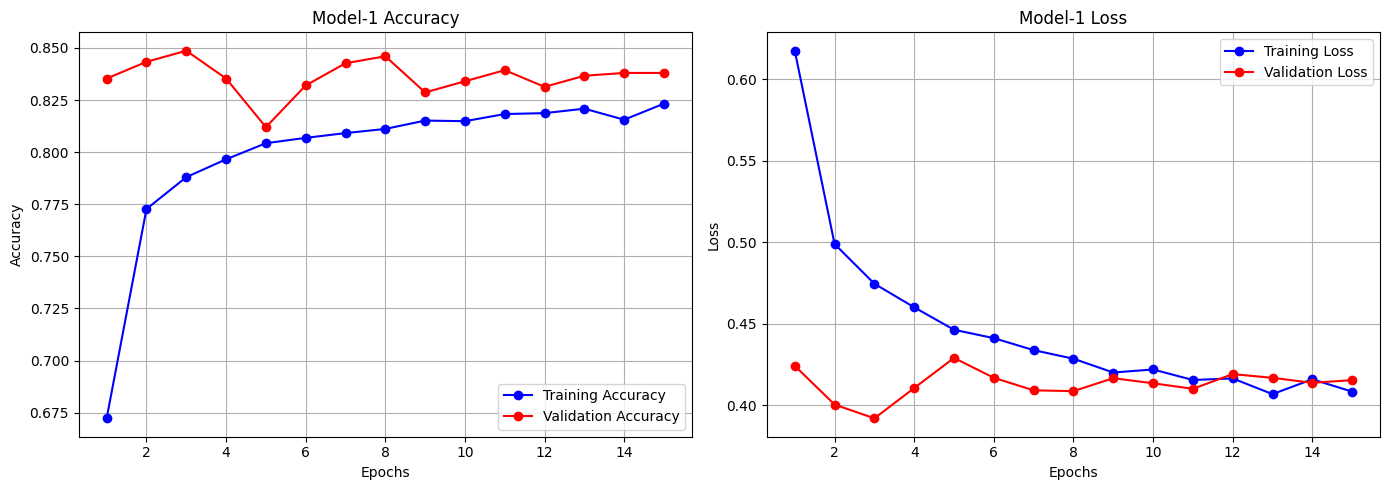

In [78]:
import matplotlib.pyplot as plt

# Extract and Plot History Values
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs = range(1, len(acc)+1)

# Plot the Graphs
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Model-1 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Model-1 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

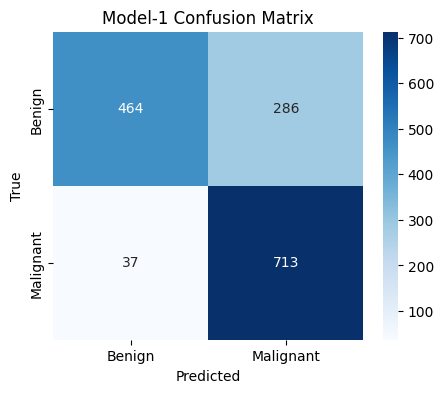

In [79]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm1 = confusion_matrix(y_true, y_pred1)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm1, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Model-1 Confusion Matrix")
plt.show()

**Model-2 " Simple threshold ROI Baseline"**

In [80]:
# Model - 2 initial setup: ROI (Region of Interest) + MobileNetV2.
# NO U-Net - Using thresholding + cropping instead of segmentation masks.

import cv2
import os
import numpy as np
import tensorflow as tf

# Simple ROI extractor (without U-Net)
def extract_roi_simple(img, size=(224,224)):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    thresh = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return cv2.resize(img, size)
    
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    roi = img[y:y+h, x:x+w]
    return cv2.resize(roi, size)

# CUSTOM GENERATOR
class ROIDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, directory, batch_size=16, shuffle=True):
        self.directory = directory
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.classes = ["benign", "malignant"]
        self.class_map = {"benign":0, "malignant":1}
        self.images, self.labels = [], []
        
        for cls in self.classes:
            folder = os.path.join(directory, cls)
            for f in os.listdir(folder):
                self.images.append(os.path.join(folder,f))
                self.labels.append(self.class_map[cls])
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.images)/self.batch_size))

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []
        for i in batch_idx:
            img = cv2.imread(self.images[i])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            roi = extract_roi_simple(img)
            
        
            roi = roi.astype('float32') / 255.0  
            
            X.append(roi)
            y.append(self.labels[i])
        return np.array(X), np.array(y)

# Generator are generated
train_gen_m2 = ROIDataGenerator(TRAIN_DIR)
val_gen_m2   = ROIDataGenerator(VAL_DIR, shuffle=False)
test_gen_m2  = ROIDataGenerator(TEST_DIR, shuffle=False)



In [81]:

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# MODEL-2 architecture
base_model2 = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model2.trainable = False

x = GlobalAveragePooling2D()(base_model2.output)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
output2 = Dense(1, activation="sigmoid")(x)
model2 = Model(base_model2.input, output2)

model2.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])


callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6)
]

history2 = model2.fit(train_gen_m2, validation_data=val_gen_m2, epochs=15, callbacks=callbacks)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


438/438 ━━━━━━━━━━━━━━━━━━━━ 38s 68ms/step - accuracy: 0.7126 - loss: 0.5624 - val_accuracy: 0.8227 - val_loss: 0.4210 - learning_rate: 1.0000e-04
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.8128 - loss: 0.4317 - val_accuracy: 0.8260 - val_loss: 0.4062 - learning_rate: 1.0000e-04
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8181 - loss: 0.4134 - val_accuracy: 0.8420 - val_loss: 0.3789 - learning_rate: 1.0000e-04
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8288 - loss: 0.3971 - val_accuracy: 0.8340 - val_loss: 0.3922 - learning_rate: 1.0000e-04
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8365 - loss: 0.3840 - val_accuracy: 0.8287 - val_loss: 0.3882 - learning_rate: 1.0000e-04
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 0.8321 - loss: 0.3753 - val_accuracy: 0.8513 - val_loss: 0.3548 - learning_rate: 1.0000e-04
Epoch 7/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accurac

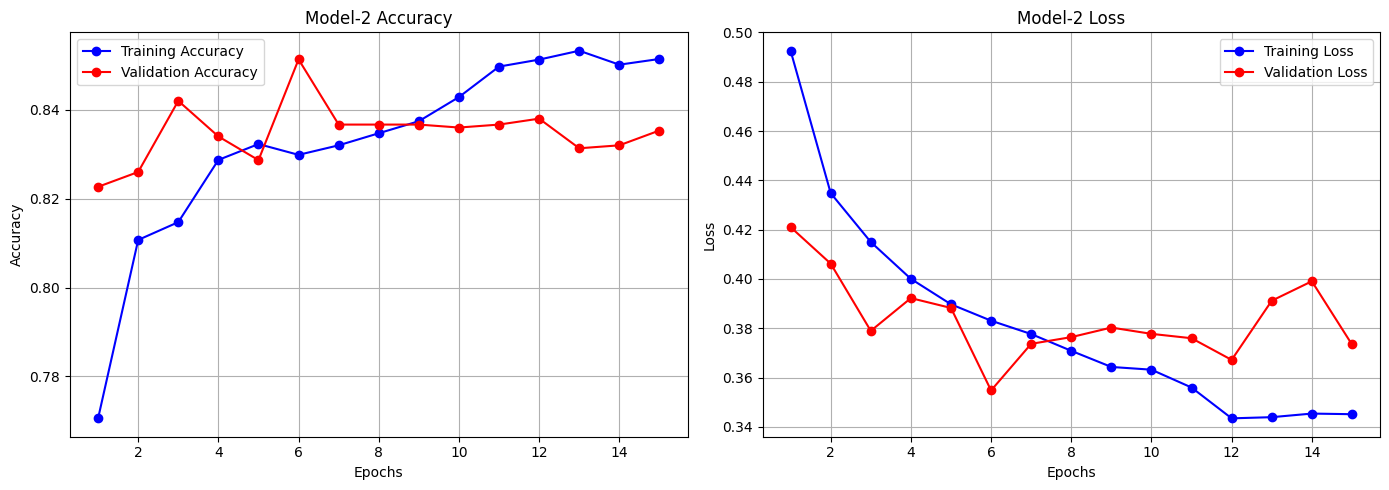

In [82]:
import matplotlib.pyplot as plt

# Extract and Plot History Values for Model-2
acc2 = history2.history['accuracy']
val_acc2 = history2.history['val_accuracy']
loss2 = history2.history['loss']
val_loss2 = history2.history['val_loss']
epochs2 = range(1, len(acc2)+1)

# Plot the Graphs
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs2, acc2, 'bo-', label='Training Accuracy')
plt.plot(epochs2, val_acc2, 'ro-', label='Validation Accuracy')
plt.title('Model-2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
plt.plot(epochs2, loss2, 'bo-', label='Training Loss')
plt.plot(epochs2, val_loss2, 'ro-', label='Validation Loss')
plt.title('Model-2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step
- MODEL-2 CLASSIFICATION REPORT -
              precision    recall  f1-score   support

      Benign       0.89      0.73      0.80       750
   Malignant       0.77      0.91      0.84       750

    accuracy                           0.82      1500
   macro avg       0.83      0.82      0.82      1500
weighted avg       0.83      0.82      0.82      1500



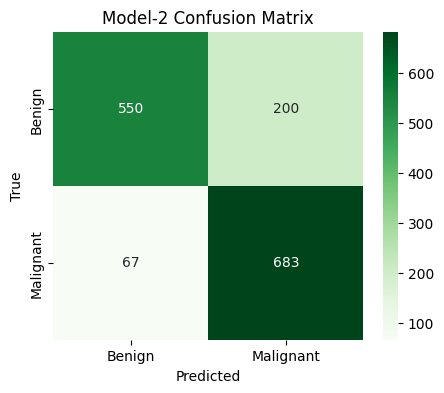

In [83]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#  TEST PREDİCTİONS
y_prob2 = model2.predict(test_gen_m2).flatten()
y_pred2 = (y_prob2 > 0.4).astype(int)

# GET TRUE LABELS
y_true2 = np.array(test_gen_m2.labels)

# CLASSIFICATION REPORT 
print("- MODEL-2 CLASSIFICATION REPORT -")
print(classification_report(y_true2, y_pred2, target_names=["Benign", "Malignant"]))

#  CONFUSION MATRIX
cm2 = confusion_matrix(y_true2, y_pred2)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm2, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Model-2 Confusion Matrix")
plt.show()


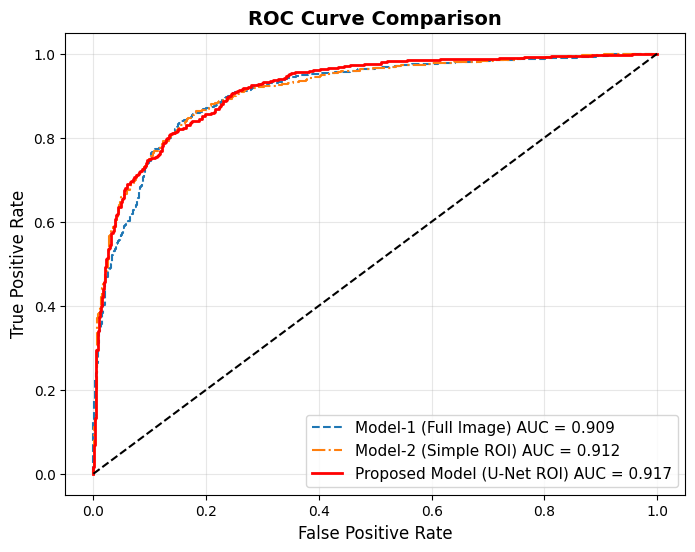

In [84]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate the ROC values for all three models
fpr1, tpr1, _ = roc_curve(y_true, y_prob1) 
auc1 = auc(fpr1, tpr1)

fpr2, tpr2, _ = roc_curve(y_true, y_prob2) 
auc2 = auc(fpr2, tpr2)

fpr3, tpr3, _ = roc_curve(y_true, y_prob_prop) 
auc3 = auc(fpr3, tpr3)

# Plot the graph
plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1, label=f"Model-1 (Full Image) AUC = {auc1:.3f}", linestyle="--")
plt.plot(fpr2, tpr2, label=f"Model-2 (Simple ROI) AUC = {auc2:.3f}", linestyle="-.")
plt.plot(fpr3, tpr3, label=f"Proposed Model (U-Net ROI) AUC = {auc3:.3f}", linewidth=2, color="red")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [88]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def run_mcnemar(y_true, y_pred_base, y_pred_proposed):
    
    # Identify the correct and incorrect answers of both models
    both_correct = np.sum((y_pred_base == y_true) & (y_pred_proposed == y_true))
    proposed_only = np.sum((y_pred_base != y_true) & (y_pred_proposed == y_true))
    base_only = np.sum((y_pred_base == y_true) & (y_pred_proposed != y_true))
    both_wrong = np.sum((y_pred_base != y_true) & (y_pred_proposed != y_true))
    
    # Contingency Table
    table = [[both_correct, base_only],
             [proposed_only, both_wrong]]
    
    result = mcnemar(table, exact=True)
    return result.pvalue

# Run the tests
p_val_vs_m1 = run_mcnemar(y_true, y_pred1, y_pred_prop)
p_val_vs_m2 = run_mcnemar(y_true, y_pred2, y_pred_prop)

print("")
print("- McNemar’s Test Results -")
print("Proposed Model vs Model-1 p-value: {:.5e}".format(p_val_vs_m1))
print("Proposed Model vs Model-2 p-value: {:.5e}".format(p_val_vs_m2))

print("")
if p_val_vs_m1 < 0.05 and p_val_vs_m2 < 0.05:
    print("RESULT: The Proposed Model is statistically significantly superior to the other two models.(p < 0.05)")
else:
    print("RESULT: No statistically significant difference was found.")


- McNemar’s Test Results -
Proposed Model vs Model-1 p-value: 1.90341e-04
Proposed Model vs Model-2 p-value: 6.23564e-01

RESULT: No statistically significant difference was found.


In [94]:
import pandas as pd
from sklearn.metrics import confusion_matrix

#  Metric calculation function 
def calculate_medical_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    TN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]
    TP = cm[1, 1]
    
    sensitivity = TP / (TP + FN)  # Recall for Malignant
    specificity = TN / (TN + FP)  # Recall for Benign
    fnr = FN / (TP + FN)          # False Negative Rate (Kanseri kaçırma oranı)
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Sensitivity (Malignant Recall)": sensitivity,
        "Specificity (Benign Recall)": specificity,
        "False Negative Rate (FNR)": fnr
    }

#  Run calculations for 3 models
metrics_m1 = calculate_medical_metrics(y_true, y_pred1, "Model-1 (Full Image)")
metrics_m2 = calculate_medical_metrics(y_true, y_pred2, "Model-2 (Simple ROI)")
metrics_prop = calculate_medical_metrics(y_true, y_pred_prop, "Proposed Model (U-Net ROI)")

analysis_rows = [metrics_prop, metrics_m1, metrics_m2]
df_analysis = pd.DataFrame(analysis_rows)

 
print("")
print("========================= MEDICAL METRICS ANALYSIS ====================")
display(df_analysis)


========================= MEDICAL METRICS ANALYSIS ====================


,Model,Accuracy,Sensitivity (Malignant Recall),Specificity (Benign Recall),False Negative Rate (FNR)
0,Proposed Model (U-Net ROI),0.829333,0.830667,0.828000,0.169333
1,Model-1 (Full Image),0.784667,0.950667,0.618667,0.049333
2,Model-2 (Simple ROI),0.822000,0.910667,0.733333,0.089333
